In [ ]:
import os
import datetime

from tqdm import tqdm
from pptools.io import load_nc_arr, ZarrWriter, ZarrReader
from pptools.visualize import Visualizer
import matplotlib.pyplot as plt
import dask.array as da
from scipy import ndimage as ndi
from trimesh.voxel import ops
import pyvista as pv


vis = Visualizer()

In [2]:
toy_tomo = ZarrReader('/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/tomo.zarr').get_dask_array()
toy_mask = ZarrReader('/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/mask.zarr').get_dask_array()

In [3]:
print(toy_tomo)

dask.array<from-zarr, shape=(1024, 1024, 1024), dtype=uint8, chunksize=(256, 256, 256), chunktype=numpy.ndarray>


In [4]:
import numpy as np
import dask.array as da
import dask
from numba import njit


@njit(nogil=True)
def _bbox_one_block(mask_block, n_labels, oz, oy, ox):
    bboxes = np.empty((n_labels + 1, 6), dtype=np.int32)
    max_int = np.iinfo(np.int32).max

    for i in range(n_labels + 1):
        bboxes[i, 0] = max_int  # zmin
        bboxes[i, 1] = -1       # zmax
        bboxes[i, 2] = max_int  # ymin
        bboxes[i, 3] = -1       # ymax
        bboxes[i, 4] = max_int  # xmin
        bboxes[i, 5] = -1       # xmax

    for z in range(mask_block.shape[0]):
        for y in range(mask_block.shape[1]):
            for x in range(mask_block.shape[2]):
                label = mask_block[z, y, x]

                if label > 0:
                    gz = z + oz
                    gy = y + oy
                    gx = x + ox

                    if gz < bboxes[label, 0]:
                        bboxes[label, 0] = gz
                    if gz + 1 > bboxes[label, 1]:
                        bboxes[label, 1] = gz + 1

                    if gy < bboxes[label, 2]:
                        bboxes[label, 2] = gy
                    if gy + 1 > bboxes[label, 3]:
                        bboxes[label, 3] = gy + 1

                    if gx < bboxes[label, 4]:
                        bboxes[label, 4] = gx
                    if gx + 1 > bboxes[label, 5]:
                        bboxes[label, 5] = gx + 1

    return bboxes


def get_particle_bounding_boxes(mask: da.Array, n_labels: int):
    n_labels = int(n_labels)

    z_offsets = np.cumsum((0,) + mask.chunks[0][:-1])
    y_offsets = np.cumsum((0,) + mask.chunks[1][:-1])
    x_offsets = np.cumsum((0,) + mask.chunks[2][:-1])

    partials = []
    block_grid = mask.to_delayed()

    for iz in range(block_grid.shape[0]):
        for iy in range(block_grid.shape[1]):
            for ix in range(block_grid.shape[2]):
                block = block_grid[iz, iy, ix]

                partial = dask.delayed(_bbox_one_block)(
                    block,
                    n_labels,
                    int(z_offsets[iz]),
                    int(y_offsets[iy]),
                    int(x_offsets[ix]),
                )
                partials.append(partial)

    partials = dask.compute(*partials)
    partials = np.stack(partials, axis=0)

    final = np.empty((n_labels + 1, 6), dtype=np.int32)

    final[:, 0] = partials[:, :, 0].min(axis=0)  # zmin
    final[:, 1] = partials[:, :, 1].max(axis=0)  # zmax
    final[:, 2] = partials[:, :, 2].min(axis=0)  # ymin
    final[:, 3] = partials[:, :, 3].max(axis=0)  # ymax
    final[:, 4] = partials[:, :, 4].min(axis=0)  # xmin
    final[:, 5] = partials[:, :, 5].max(axis=0)  # xmax

    missing = final[:, 1] == -1
    final[missing] = -1

    return final

In [5]:
labels = da.unique(toy_mask).compute()[1:]
print(labels)

[  82   96   97   99  101  115  117  118  119  244  258  260  261  276
  278  419  430  431  535  538  542  560  561  683  688  689  690  691
  692  693  694  695  696  697  698  699  700  701  702  704  706  708
  709  712  810  811  820  821  822  823  824  825  826  827  829  830
  831  832  833  836  837  840  841  842  843  844  847  849  963  966
  967  968  969  976  978  980  984  988  991  994  996 1140 1155 1157
 1162 1168 1169 1277 1279 1280 1281 1282 1283 1284 1285 1286 1287 1288
 1289 1290 1291 1292 1293 1294 1295 1296 1297 1298 1299 1300 1301 1302
 1303 1304 1306 1307 1308 1309 1428 1430 1431 1433 1434 1435 1436 1437
 1438 1439 1440 1444 1446 1448 1450 1453 1574 1579 1580 1584 1587 1588
 1593 1594 1595 1596 1612 1617 1744 1747 1748 1811 1812 1813 1817 1819
 1822 1943 1944 1945 1946 1947 1948 1951 1956 1957 1958 1959 1961 2074]


In [6]:
boxes = get_particle_bounding_boxes(toy_mask, np.max(labels))

In [17]:
def extract_objects_3d(
    image,
    mask,
    labels,
    boxes,
    simp_percent,
    simp_max_faces,
    output_dir
):
    """
    Extract each labelled object from a 3D image.

    Parameters
    ----------
    image:
        3D image array with shape (z, y, x).
    mask:
        3D label mask with the same shape as image.
    labels:
        Label IDs to extract, e.g. [10, 30, 51, 62].
    boxes:
        Dictionary where boxes[label_id] = (zmin, zmax, ymin, ymax, xmin, xmax).

    Returns
    -------
    objects:
        Dictionary mapping label_id -> extracted 3D image.
        Voxels outside the object mask are set to 0.
    """

    if image.shape != mask.shape:
        raise ValueError(f"image and mask must have the same shape, got {image.shape} and {mask.shape}")

    labels = labels[labels > 0]
    for label_id in tqdm(labels):
        zmin, zmax, ymin, ymax, xmin, xmax = boxes[label_id]
        cropped_image = image[zmin:zmax, ymin:ymax, xmin:xmax]
        cropped_mask = mask[zmin:zmax, ymin:ymax, xmin:xmax]
        extracted_image = da.where(cropped_mask == label_id, cropped_image, 0).compute()
        np.save(os.path.join(output_dir, f"{label_id}.npy"), extracted_image)
        extracted_mesh = ops.matrix_to_marching_cubes(extracted_image)
        target_faces = min(simp_max_faces, extracted_mesh.faces.shape[0] * (1 - simp_percent))
        extracted_mesh_simp = extracted_mesh.simplify_quadric_decimation(face_count=target_faces)
        # extracted_mesh_simp = extracted_mesh.simplify_quadric_decimation(0.95)
        extracted_mesh_simp.export(os.path.join(output_dir, f"{label_id}.obj"))

In [18]:
extracted_objects = extract_objects_3d(toy_tomo, toy_mask, labels, boxes, 0.97, 8000, '/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/tmp')

100%|██████████| 168/168 [01:42<00:00,  1.64it/s]


(204, 121, 172)
(248264, 3) (12412, 3)


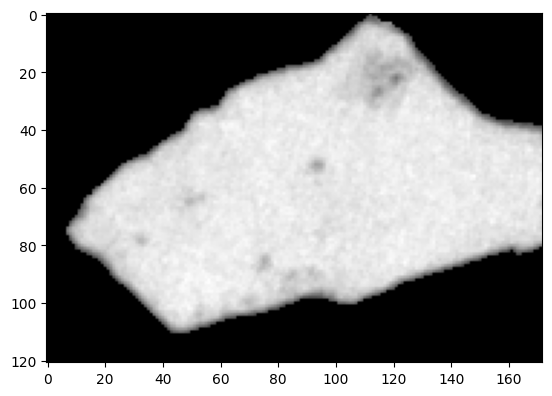

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [23]:
obj_id = 1450
obj_tomo = extracted_objects[obj_id].compute()
print(obj_tomo.shape)
obj_mesh = ops.matrix_to_marching_cubes(obj_tomo)
obj_mesh_simp = obj_mesh.simplify_quadric_decimation(0.95)
print(obj_mesh.faces.shape, obj_mesh_simp.faces.shape)
plt.imshow(obj_tomo[obj_tomo.shape[0] // 2], cmap='gray')
plt.show()

pv.set_jupyter_backend('html')
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(obj_mesh)
plotter.show()
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(obj_mesh_simp)
plotter.show()

In [15]:
obj_82 = extracted_objects[82].compute()

In [16]:
obj_82_mesh = ops.matrix_to_marching_cubes(obj_82)

In [29]:
obj_82_mesh_simplify = obj_82_mesh.simplify_quadric_decimation(0.95)

In [30]:
print(obj_82_mesh.faces.shape, obj_82_mesh_simplify.faces.shape)

(110356, 3) (5516, 3)


In [31]:
pv.set_jupyter_backend('html')

plotter = pv.Plotter(notebook=True)
plotter.add_mesh(obj_82_mesh)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [32]:
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(obj_82_mesh_simplify)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

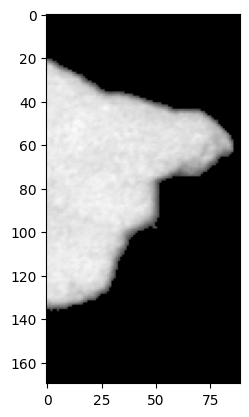

In [13]:
plt.imshow(obj_82[obj_82.shape[0] // 2], cmap='gray')
plt.show()